In [62]:
import pandas as pd 

class DataLoader:
    def __init__(self, DATA_PATH: str):
        self.DATA_PATH = DATA_PATH #store the file path of the dataset 
        
    def load_data(self) -> pd.DataFrame:
        #reads the CSV file
        #convert the "time" column into datetime format
        return pd.read_csv(self.DATA_PATH, parse_dates=["time"])

In [63]:
#feature selection
class Preprocessor:
    def __init__(self):
        self.target = "mag" #variable that is being predicted

    def preprocess(self, data):
        #sort the dataset by time 
        data = data.sort_values(by='time').reset_index(drop=True)

        if 'nst' in data.columns:
            data['nst'] = data['nst'].fillna(data['nst'].median())
            #nst = number of seismic stations that detected the earthquake
            #replace missing values with 0
        if 'gap' in data.columns:
            data['gap'] = data['gap'].fillna(data['gap'].median())
            #largest gap between stations, if the gap is missing, replace with median
        if 'dmin' in data.columns:
            data['dmin'] = data['dmin'].fillna(data['dmin'].median())
            #dmin = distance to nearest station, replace missing values with median
        if 'rms' in data.columns:
            data['rms'] = data['rms'].fillna(data['rms'].median())
            #rms = root mean square of travel time residuals, a residual is the difference between an observed value and the value predicted by a statistical model
            #missing values are replaced with the median

        columns_to_keep = ['time', 'latitude', 'longitude', 'depth', 'mag', 
                           'nst', 'gap', 'dmin', 'rms']
        
        #Only keep the columns that exist in the dataframe
        existing_columns = [col for col in columns_to_keep if col in data.columns]
        data = data[existing_columns]
        #Rolling Window Features
        #these give the Random Forest context about recent activity 
        #average magnitude of the last 10 earthquakes
        data['rolling_mean'] = data['mag'].rolling(window=10).mean().shift(1)
        
        # max magnitude of the last 10 earthquakes
        data['rolling_max'] = data['mag'].rolling(window=10).max().shift(1)
        
        # how much magnitudes varied in the last 10 earthquakes
        data['rolling_std'] = data['mag'].rolling(window=10).std().shift(1)
        
        # calculate the number of days since the previous earthquake
        data['days_since_last'] = data['time'].diff().dt.total_seconds() / 86400
        #replace missing value in the first row with 0
        data['days_since_last'] = data['days_since_last'].fillna(0)

        # remove rows that contain Not a Number values created by the rolling window
        data = data.dropna()

        return data

In [64]:
class TimeSplit: #Split the dataset into training and testing data
    def __init__(self, split_year: int = 2015):
        self.split_year = split_year
    #function to split the dataset
    def split(self, data: pd.DataFrame):
        #training data = earthquakes before or during the year
        train = data[data["time"].dt.year <= self.split_year]
        #test data = earthquakes after the split year
        test = data[data["time"].dt.year > self.split_year]

        #Selected Features for the model
        features = [
            "depth", "days_since_last", "rolling_mean", "rolling_max", "latitude",
            "rolling_std", "longitude"
        ]

        print("\nChecking engineered features:")
        print(data[['rolling_mean', 'rolling_max', 'rolling_std', 'days_since_last']].head()) #check if engineered features were created

        required_features = ['rolling_mean', 'rolling_max', 'rolling_std', 'days_since_last']
        for feature in required_features:
            assert feature in data.columns, f"{feature} not found"

        #only keep features that exist in the dataset 
        available_features = [f for f in features if f in data.columns]
        #training input features
        x_train = train[available_features]
        #training target variable
        y_train = train["mag"]
        #testing input features
        x_test = test[available_features]
        #testing target variable
        y_test = test["mag"]
        
        print("\nTrain/Test Split:")
        print("Train shape:", x_train.shape) #total records and total features of training dataset
        print("Test shape:", x_test.shape) #total records and total features of testing dataset

        print("Train max date:", train['time'].max()) #training data max date
        print("Test min date:", test['time'].min()) #testing data minimum date

        return x_train, x_test, y_train, y_test

In [65]:
from sklearn.preprocessing import StandardScaler
#scale the features for Feedforward Neural Network
class FeatureScale:
    def __init__(self):
        self.scaler = StandardScaler()
    #fit scaler on training data and transform it 
    def fit_transform(self, x_train):
        return self.scaler.fit_transform(x_train)
    #apply transformation to test data
    def transform(self, x_test):
        return self.scaler.transform(x_test)

In [66]:
from abc import ABC, abstractmethod

class IModel(ABC):
    @abstractmethod #any model must implement a training function
    def train(self, x_train, y_train): 
        pass
    
    @abstractmethod  #any model must implement a prediciton function
    def predict(self, x_test):
        pass

In [67]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

class RandomForestModel(IModel):
    def __init__(self, n_estimators=300, max_depth=8, min_samples_leaf=4, random_state=42):
        self.model = RandomForestRegressor(
            n_estimators = n_estimators, #number of trees 
            max_depth = max_depth, #maximum depth of each tree
            min_samples_leaf = min_samples_leaf, #minimum number of samples required to be at a leaf node and prevents overfitting
            random_state = random_state, #a number for the random state to ensure results are reproducible
            n_jobs=-1 #instructs the program to use all available CPU cores to train the trees
        )

    def train(self, x_train, y_train): #train model
        self.model.fit(x_train, y_train) 

    def predict(self, x_test): #generate predictions
        return self.model.predict(x_test)
        
    def importance(self, feature_names): #generate feature importance
        return dict(zip(feature_names, self.model.feature_importances_)) 

In [68]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

class FeedForwardNetwork(IModel):
    def __init__(self, input_dim):
        self.input_dim = input_dim #stores the number of input dimensions
        self.model = self.build_model() #create the neural network

    def build_model(self):
        model = Sequential([ 
            Input(shape=(self.input_dim,)), #input layer specifying how many features the model should expect
            Dense(64, activation="relu"), #hidden layer with 64 neurons using the ReLU activation function
            Dropout(0.2), #randomly drop 20% of neurons to prevent overfitting
            Dense(32, activation="relu"), #hidden layer with 32 neurons using the ReLU activation function
            Dropout(0.1),
            Dense(16, activation="relu"), #hidden layer with 16 neurons using the ReLU activation function
            Dense(1, activation="linear") #output layer with 1 neuron using a linear activation function
        ])
        #compile neural network using the Adam optimiser and Mean Squared Error for the loss function
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mse"])
        
        return model

    def train(self, x_train, y_train):
        early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True) #apply early stop if validation loss does not improve for 20 epochs, and keep best weights
        split_index = int(len(x_train) * 0.8) #calculates the index to split the training data into 80% training and 20% validation
        x_tr = x_train[:split_index] #gets the first 80% of features for actual training 
        y_tr = y_train[:split_index] #gets the first 80% of targets for actual training
        x_val = x_train[split_index:] #gets the remaining 20% of features for validation
        y_val = y_train[split_index:] #gets the remaining 20% of targets for validation
        #trains the model for up to 600 epochs in batches of 64, using the validaiton set and early stopping
        self.history = self.model.fit(x_tr, y_tr, validation_data=(x_val, y_val),
                                      epochs=600, batch_size=64, callbacks=[early_stop], verbose = 0)

    def predict(self, x_test):
        return self.model.predict(x_test).flatten() #generates predictions
    

In [69]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#calculate regression metrics
class RegressionEvaluator:
    @staticmethod
    def regression_metrics(y_true, y_pred):
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        return {
            "MSE": mse, #measures the squared difference between predicted and actual values
            "RMSE": rmse, #measures the average difference between predicted values and actual observed values in a model
            "MAE": mae, #average absolute difference between predicted and actual values
            "R2": r2 #coefficient of determination = measures how well the model explains the varience
        }


In [70]:
#visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
#visualiser class to create graphs and charts 
class Visualise:
    #feature importance bar chart
    @staticmethod
    def plot_feature_importance(importance:dict):
        plt.figure()
        plt.bar(importance.keys(), importance.values())
        plt.title("Random Forest Feature Importance")
        plt.xlabel("Feature")
        plt.ylabel("Importance")
        plt.xticks(rotation=45) 
        plt.show()

    ##validation loss
    @staticmethod
    def plot_loss(history):
        plt.figure()
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.show()

    #magnitude vs number of occurances graph
    @staticmethod
    def plot_magnitude_distribution(data):
        plt.figure(figsize=(10, 6))
        plt.hist(data["mag"], bins=30, edgecolor="black", alpha=0.7)
        plt.title("Earthquake Magnitude vs Number of Occurrences")
        plt.xlabel("Earthquake Magnitude")
        plt.ylabel("Number of Occurrences")
        plt.show()

    #heatmap
    @staticmethod
    def correlation_heatmap(data):
        plt.figure(figsize=(10, 8))
        corr = data.corr()
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
        plt.xticks(rotation=45) 
        plt.title("Feature Correlation Matrix")
        plt.show()

    #actual vs predicted graph for Random Forest model
    @staticmethod
    def plot_results(y_true, y_pred):
        plt.figure(figsize=(10, 6))
        plt.scatter(y_true, y_pred, alpha=0.5, color='blue', label='Predictions')
        
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
        plt.xlabel("Actual Magnitude")
        plt.ylabel("Predicted Magnitude")
        plt.title("Random Forest Regression: Actual vs Predicted")
        plt.legend()
        plt.show()

    #actual vs predicted graph for Neural Network model
    @staticmethod
    def plot_network_results(y_test_np, ff_predictions):
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test_np, ff_predictions, alpha=0.5, color='blue', label='Predictions')

        min_val = min(y_test_np.min(), ff_predictions.min())
        max_val = max(y_test_np.max(), ff_predictions.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

        plt.xlabel("Actual Magnitude")
        plt.ylabel("Predicted Magnitude")
        plt.title("Neural Network: Actual vs Predicted")
        plt.legend()
        plt.show()
    
    

Data Loaded successfully
Dataset shape: (1117, 22)

Missing values before cleaning:
time                 0
latitude             0
longitude            0
depth                0
mag                  0
magType              0
nst                  5
gap                  2
dmin                68
rms                  4
net                  0
id                   0
updated              0
place                0
type                 0
horizontalError    179
depthError          12
magError           610
magNst              22
status               0
locationSource       0
magSource            0
dtype: int64

Missing values after cleaning:
time               0
latitude           0
longitude          0
depth              0
mag                0
nst                0
gap                0
dmin               0
rms                0
rolling_mean       0
rolling_max        0
rolling_std        0
days_since_last    0
dtype: int64

Checking engineered features:
    rolling_mean  rolling_max  rolling_std  days

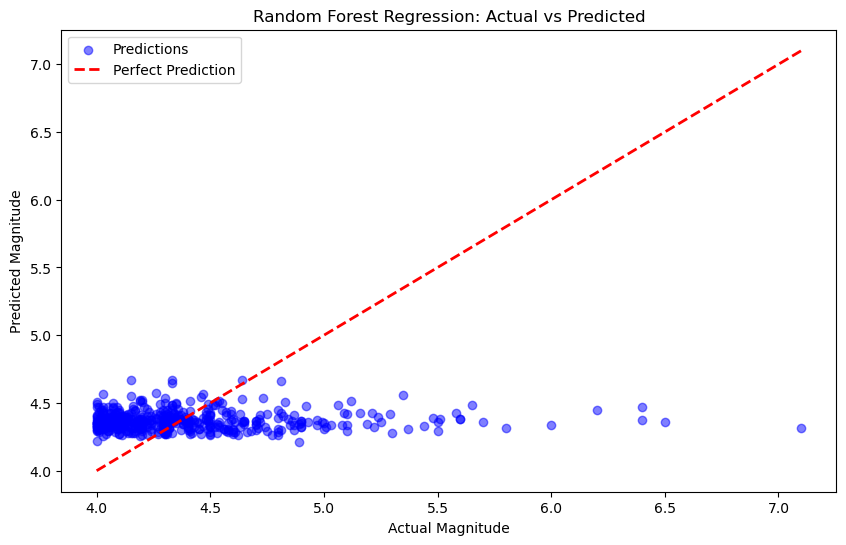

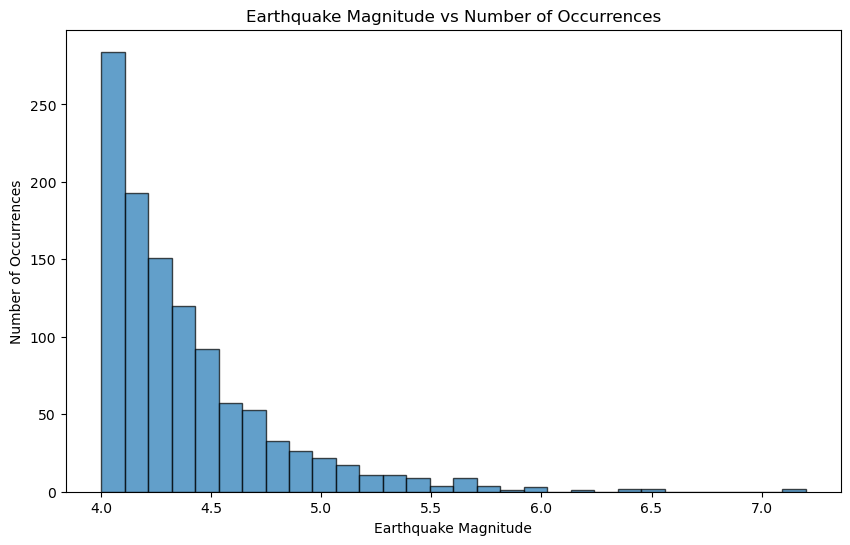

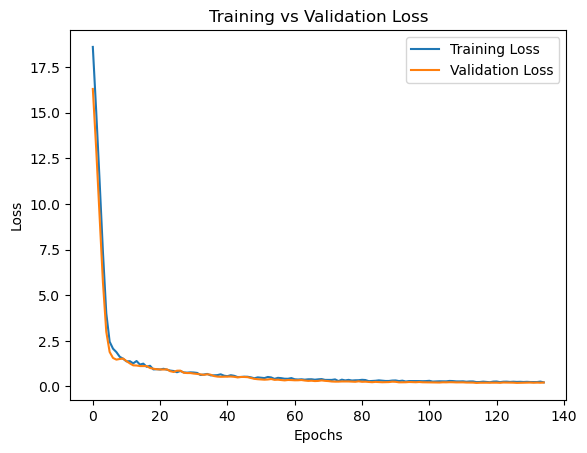

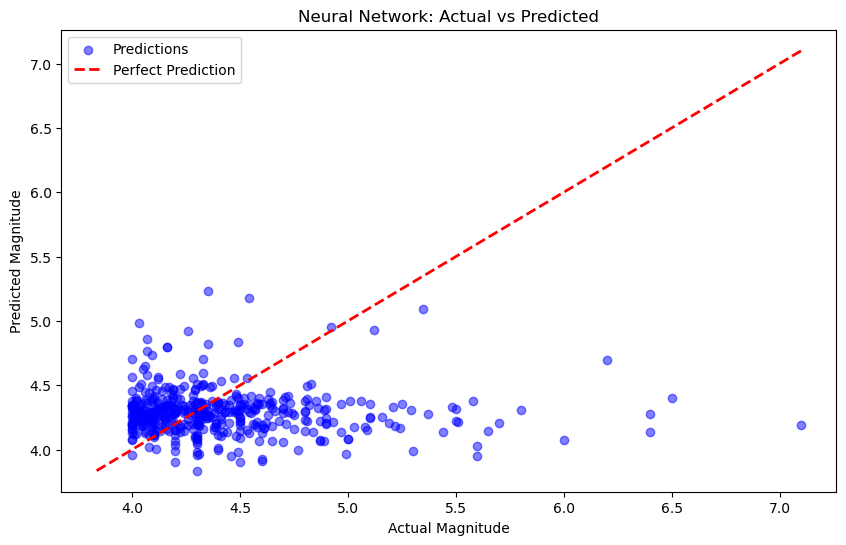

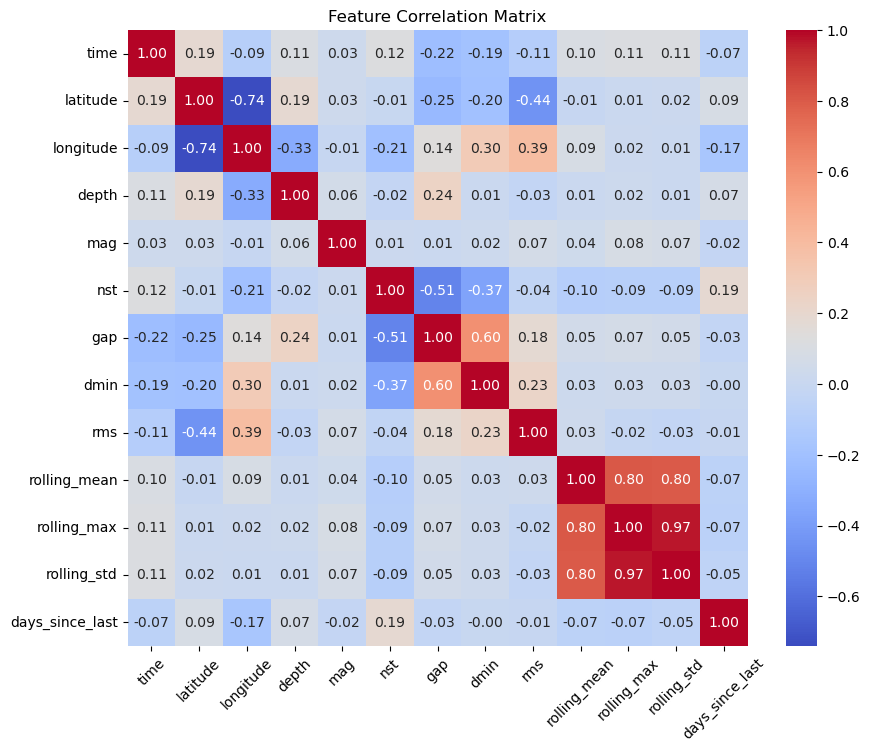

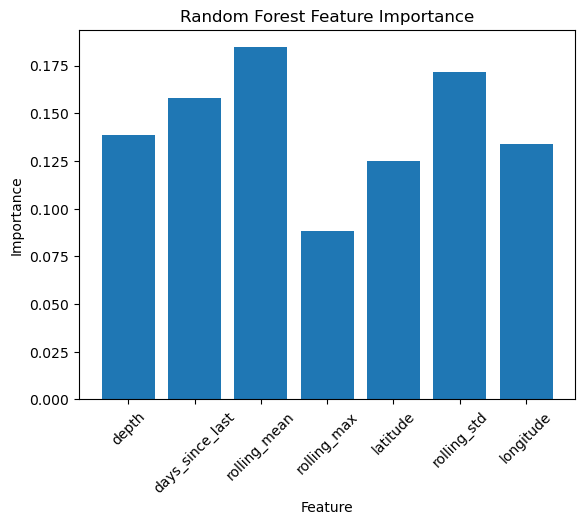


Pipeline executed successfully from start to finish


In [71]:
import numpy as np
from sklearn.metrics import mean_squared_error
import os

class MainController:
    def __init__(self, data_filepath):
        self.data_filepath = data_filepath
        
        self.loader = DataLoader(self.data_filepath)
        self.preprocessor = Preprocessor()
        self.splitter = TimeSplit(split_year=2015)
        self.evaluator = RegressionEvaluator()
        self.scaler = FeatureScale()
        
        self.rf_model = RandomForestModel()

    def execute_pipeline(self):
        if not os.path.exists(self.data_filepath): #checks if the file exists on the computer
            print("Please check the filepath and ensure the data exists before running.")
            return

        try:
            #load data
            data = self.loader.load_data() #uses the data loader to read the dataset into a variable 
            
            #check if data is None or contains no records
            if data is None or (hasattr(data, 'empty') and data.empty):
                print(f"The file '{self.data_filepath}' is empty or could not be parsed.")
                return
                
            #ensure dataset has enough rows/columns to train an ML model
            if data.shape[0] < 10 or data.shape[1] < 2: #checks if there are fewer than 10 rows or less than 2 columns
                print(f"Dataset is too small to perform machine learning. Current shape: {data.shape}")
                return
                
            print("Data Loaded successfully")
            print("Dataset shape:", data.shape)
        
        #preprocess data
            print("\nMissing values before cleaning:")
            print(data.isnull().sum()) #calculates and prints the total number of missing values per column
            assert data is not None, "Data failed to load!"
        
            data = self.preprocessor.preprocess(data) #passes the data through the preprocessor class to clean it
            print("\nMissing values after cleaning:")
            print(data.isnull().sum()) #prints missing values again to confirm cleaning worked

            assert not data.isnull().values.any(), "Missing values still exist after preprocessing"
        #Train/Test Split (Chronological)
            x_train, x_test, y_train, y_test = self.splitter.split(data) #splits the data set into training and testing features and targets

        #train and Evaluate Random Forest
            print("\nTraining Random Forest")
            self.rf_model.train(x_train, y_train) #trains the Random Forest model using the training data
            print("Random forest trained successfully")
            rf_predictions = self.rf_model.predict(x_test) #uses the trained Random Forest model to predict outcomes for the test set
            assert len(rf_predictions) == len(y_test), "Failed to produce predictions for Random Forest"
            rf_metrics = self.evaluator.regression_metrics(y_test, rf_predictions) #calculates the accuracy metrics

        #feature Scaling (For Neural Network)
            x_train_scaled = self.scaler.fit_transform(x_train) #calculates scaling parameters from the training set and applies them to the neural network 
            x_test_scaled = self.scaler.transform(x_test) #applies scaling to the test set

        #convert to numpy arrays for Keras
            x_train_scaled = np.array(x_train_scaled)
            x_test_scaled = np.array(x_test_scaled)
            y_train_np = np.array(y_train)
            y_test_np = np.array(y_test)

            print("\nFeature scaling applied successfully")
            print("Sample scaled data:", x_train_scaled[:5])#prints 5 rows of scaled data
            assert not np.isnan(x_train_scaled).any(), "Scaling produced NaN values" #ensures the scaling process did not produce Not a Number errors
        #train and evaluate Feedforward Neural Network
            print("Training Feedforward Neural Network")
            self.ff_model = FeedForwardNetwork(input_dim=x_train_scaled.shape[1]) #creates the neural network model 
            self.ff_model.train(x_train_scaled, y_train_np) #trains the neural network on scaled training data
            print("Neural Network trained successfully") 
            ff_predictions = self.ff_model.predict(x_test_scaled) #uses the trained neural network to predict outcomes for the scaled test set 
            assert len(ff_predictions) == len(y_test_np), "Failed to produce predictions for Neural network" #ensures the number of neural network predictions matches the test set size
            nn_metrics = self.evaluator.regression_metrics(y_test_np, ff_predictions) #calculates accuracy metrics for the neural network

        #baseline Evaluation
            baseline_prediction = np.mean(y_train) #calculates an averate of training targets to use as the baseline model
            y_pred_baseline = np.full_like(y_test, baseline_prediction) #creates an array the same size as y_test, filled with the baseline average
            baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline)) #calculates the Root Mean Squared Error of the baseline model

            print("\nBaseline prediction created successfully")
            assert baseline_rmse > 0, "Baseline RMSE invalid" #ensures the baseline error is more than 0 
        #output Comparative Results
            self.print_results(nn_metrics, rf_metrics, baseline_rmse, y_train, y_test)

        #visualise
            print("\nGenerating Visualisations...")
            Visualise.plot_results(y_test, rf_predictions)
            Visualise.plot_magnitude_distribution(data)
            Visualise.plot_loss(self.ff_model.history)
            Visualise.plot_network_results(y_test_np, ff_predictions)
            Visualise.correlation_heatmap(data)
        
            importance = self.rf_model.importance(x_train.columns)
            Visualise.plot_feature_importance(importance)

            print("\nPipeline executed successfully from start to finish")
            assert True, "Pipeline failed"

        except Exception as e:
            print(f"An error occurred during pipeline execution: {e}")
    #print results
    def print_results(self, nn_metrics, rf_metrics, baseline_rmse, y_train, y_test):
        print("\n" + "="*30)
        print("NEURAL NETWORK RESULTS")
        print("="*30)
        for metric, value in nn_metrics.items():
            print(f"{metric}: {value:.4f}")
        
        print("\n" + "="*30)
        print("RANDOM FOREST RESULTS")
        print("="*30)
        print(f"RMSE: {rf_metrics['RMSE']:.4f}")
        print(f"MSE:  {rf_metrics['MSE']:.4f}")
        print(f"MAE:  {rf_metrics['MAE']:.4f}")
        print(f"R2:   {rf_metrics['R2']:.4f}")
        
        print("\n" + "="*30)
        print("BASELINE & DISTRIBUTION")
        print("="*30)
        print(f"Baseline RMSE: {baseline_rmse:.4f}")
        print(f"Train mean:    {y_train.mean():.4f}")
        print(f"Test mean:     {y_test.mean():.4f}")
        print(f"Train std:     {y_train.std():.4f}")
        print(f"Test std:      {y_test.std():.4f}")
        print("="*30)


if __name__ == "__main__":
    controller = MainController("earthquake_data.csv")
    controller.execute_pipeline()